# Telco Customer Churn — Exploratory Data Analysis

This notebook explores the **IBM Telco Customer Churn** dataset (~7,043 customers) to
understand what drives churn before modelling.

We look at:

1. Overall churn rate and class balance
2. Churn by **Contract** type
3. Churn across **tenure**
4. Churn across **MonthlyCharges**
5. Churn by **InternetService**
6. A **correlation heatmap** of the numeric features

Key figures are saved to `../reports/` so they can be reused in the README and slides.

> Run `python data/download_data.py` first if `data/Telco-Customer-Churn.csv` is missing.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the src/ package importable so we reuse the same loading/cleaning logic
# that training uses (single source of truth, no divergence between EDA and model).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from preprocess import load_dataset, clean_dataset  # noqa: E402

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Fathma\Downloads\churn_predictor


In [2]:
# Load the raw CSV and take a first look.
raw = load_dataset()
print("Shape:", raw.shape)
raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Column types and missingness. Note: TotalCharges is stored as an object because a
# handful of brand-new customers (tenure == 0) have a blank string instead of a number.
raw.info()
blank_total_charges = (raw["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"\nBlank TotalCharges values: {blank_total_charges}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 1. Overall churn rate

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.5%


C:\Users\Fathma\AppData\Local\Temp\ipykernel_4820\2699761911.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=raw, order=["No", "Yes"], palette=["#4c72b0", "#dd8452"], ax=ax)


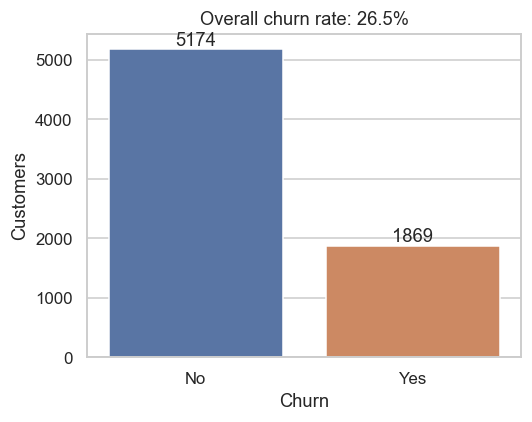

In [4]:
churn_counts = raw["Churn"].value_counts()
churn_rate = raw["Churn"].eq("Yes").mean()
print(churn_counts)
print(f"\nOverall churn rate: {churn_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Churn", data=raw, order=["No", "Yes"], palette=["#4c72b0", "#dd8452"], ax=ax)
ax.set_title(f"Overall churn rate: {churn_rate:.1%}")
ax.set_ylabel("Customers")
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_churn_rate.png", bbox_inches="tight")
plt.show()

The classes are imbalanced (~27% churn). This is why training uses `scale_pos_weight`
for XGBoost and `class_weight="balanced"` for logistic regression, and why we report
ROC-AUC / PR-AUC and the **churn-class** precision/recall rather than plain accuracy.

## 2. Churn by contract type

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object


C:\Users\Fathma\AppData\Local\Temp\ipykernel_4820\3190490659.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="flare", ax=ax)


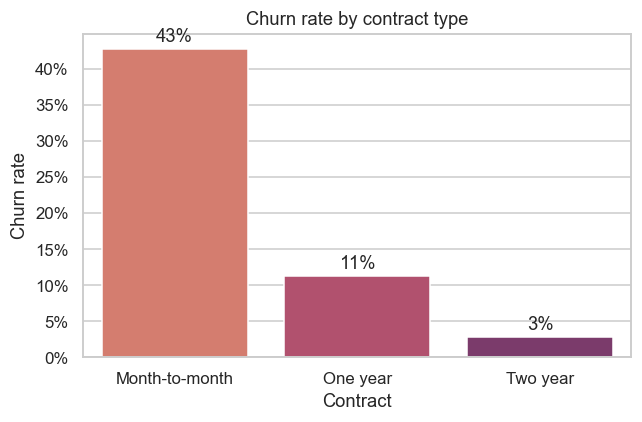

In [5]:
contract_churn = (
    raw.groupby("Contract")["Churn"].apply(lambda s: s.eq("Yes").mean()).sort_values(ascending=False)
)
print((contract_churn * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="flare", ax=ax)
ax.set_title("Churn rate by contract type")
ax.set_ylabel("Churn rate")
ax.set_xlabel("Contract")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for i, v in enumerate(contract_churn.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_churn_by_contract.png", bbox_inches="tight")
plt.show()

Month-to-month customers churn far more than those on one- or two-year contracts —
the single strongest categorical signal in the data.

## 3. Churn across tenure

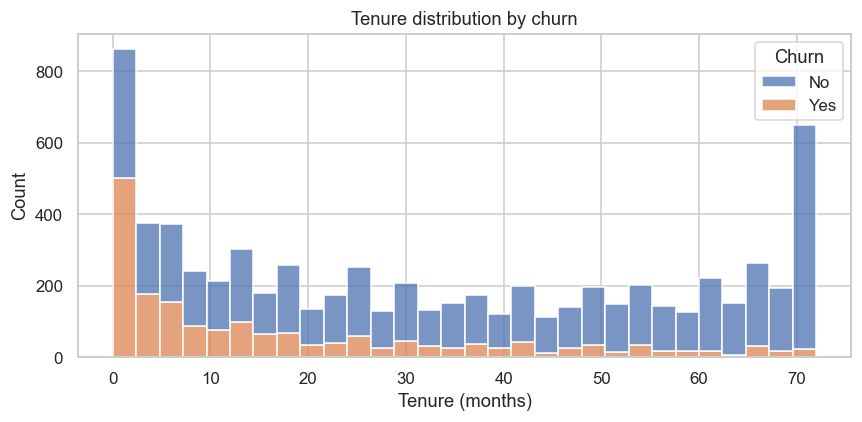

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=raw, x="tenure", hue="Churn", bins=30, multiple="stack",
    palette=["#4c72b0", "#dd8452"], hue_order=["No", "Yes"], ax=ax,
)
ax.set_title("Tenure distribution by churn")
ax.set_xlabel("Tenure (months)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_churn_by_tenure.png", bbox_inches="tight")
plt.show()

Churn is concentrated in the first few months of tenure and drops sharply for
long-tenured customers — early lifecycle is the highest-risk window.

## 4. Churn across monthly charges

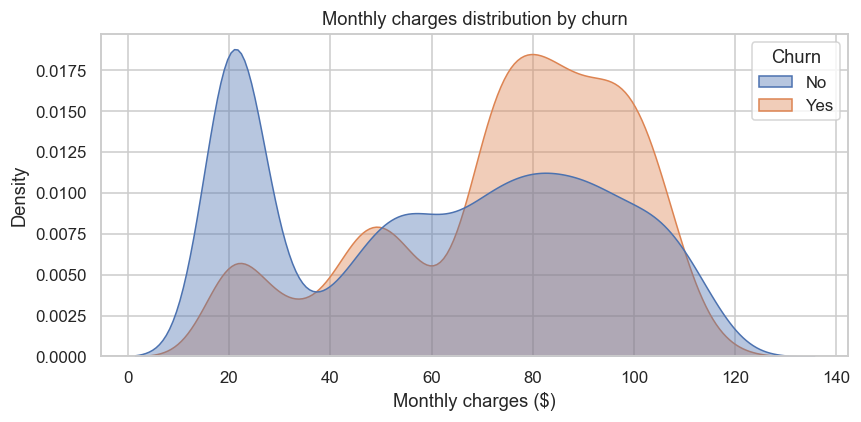

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(
    data=raw, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False,
    palette=["#4c72b0", "#dd8452"], hue_order=["No", "Yes"], alpha=0.4, ax=ax,
)
ax.set_title("Monthly charges distribution by churn")
ax.set_xlabel("Monthly charges ($)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_churn_by_monthlycharges.png", bbox_inches="tight")
plt.show()

Churners skew toward higher monthly charges (roughly \$70+), often tied to
fiber-optic internet.

## 5. Churn by internet service

InternetService
Fiber optic    41.9%
DSL            19.0%
No              7.4%
Name: Churn, dtype: object


C:\Users\Fathma\AppData\Local\Temp\ipykernel_4820\3050923199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=internet_churn.index, y=internet_churn.values, palette="crest", ax=ax)


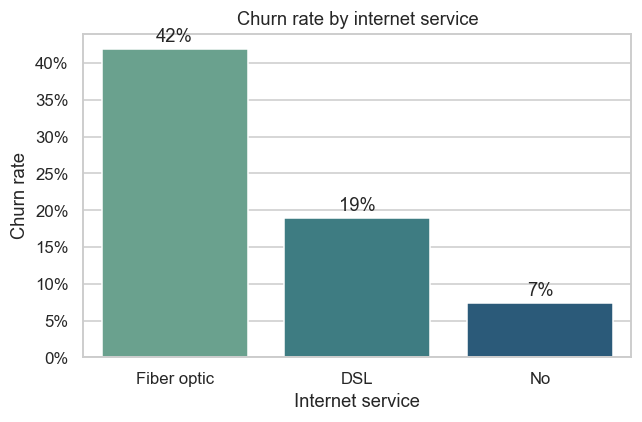

In [8]:
internet_churn = (
    raw.groupby("InternetService")["Churn"].apply(lambda s: s.eq("Yes").mean()).sort_values(ascending=False)
)
print((internet_churn * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=internet_churn.index, y=internet_churn.values, palette="crest", ax=ax)
ax.set_title("Churn rate by internet service")
ax.set_ylabel("Churn rate")
ax.set_xlabel("Internet service")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for i, v in enumerate(internet_churn.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_churn_by_internetservice.png", bbox_inches="tight")
plt.show()

Fiber-optic customers churn at a much higher rate than DSL or no-internet customers,
consistent with the higher monthly charges seen above.

## 6. Correlation heatmap (numeric features)

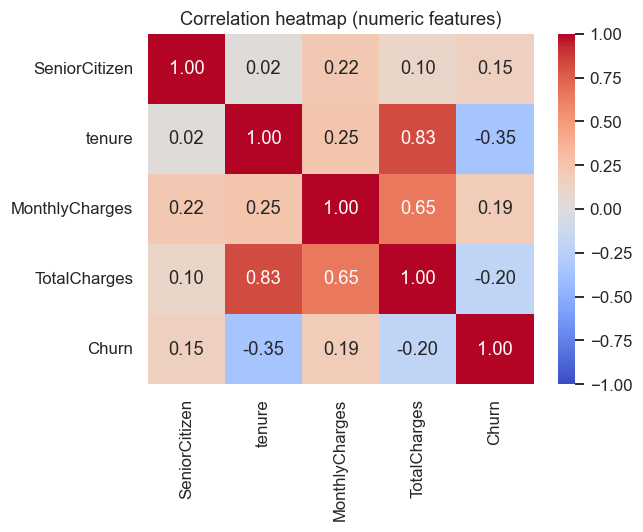

In [9]:
# clean_dataset coerces TotalCharges to numeric and maps Churn -> 1/0, so we get a
# meaningful numeric correlation matrix including the target.
cleaned = clean_dataset(raw)
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr = cleaned[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Correlation heatmap (numeric features)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Takeaways

- **~27% overall churn** — an imbalanced target, handled at model time.
- **Contract type** is the dominant categorical driver: month-to-month churns most.
- **Low tenure** and **high monthly charges** strongly associate with churn.
- **Fiber-optic** internet customers are the highest-risk service segment.
- `tenure` and `TotalCharges` are strongly correlated (longer tenure → more billed),
  which the tree model handles without manual removal.

All figures are saved under `reports/` for reuse in the README and presentations.